# QuickDraw (apple)
This notebook trains a tiny GAN on **QuickDraw apple** sketches (28×28)

In [1]:
import os, sys, math, random
import numpy as np

In [2]:
DATA_PATH = "apple.npy"

X = np.load(DATA_PATH)

LIMIT_ROWS = 60000
if LIMIT_ROWS is not None:
    X = X[:LIMIT_ROWS]

print("Loaded:", X.shape, X.dtype)

Loaded: (60000, 784) uint8


In [3]:
X = X.astype(np.float32)
X = (X / 255.0) * 2.0 - 1.0
X = X.reshape(-1, 1, 28, 28)

# Deterministic train/val split
N = X.shape[0]
val_size = min(5000, N // 10)
train_X = X[:-val_size]
val_X = X[-val_size:]

print("train:", train_X.shape, "val:", val_X.shape)

train: (55000, 1, 28, 28) val: (5000, 1, 28, 28)


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

train_ds = TensorDataset(torch.from_numpy(train_X))
val_ds = TensorDataset(torch.from_numpy(val_X))

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)


Device: cpu


In [5]:
latent_dim = 64

class Generator(nn.Module):
    def __init__(self, z_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 784),
            nn.Tanh(),  # output in [-1,1]
        )

    def forward(self, z):
        x = self.net(z)
        return x.view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)

G = Generator(latent_dim).to(device)
D = Discriminator().to(device)

print("Params(G):", sum(p.numel() for p in G.parameters()))
print("Params(D):", sum(p.numel() for p in D.parameters()))


Params(G): 550416
Params(D): 533505


In [6]:
criterion = nn.BCELoss()

lr = 2e-4
beta1, beta2 = 0.5, 0.999

opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2))


In [7]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

def show_samples(G, n=36):
    G.eval()
    with torch.no_grad():
        z = torch.randn(n, latent_dim, device=device)
        fake = G(z).cpu()
        fake = (fake + 1) / 2  # [-1,1] -> [0,1]
        grid = make_grid(fake, nrow=int(math.sqrt(n)))
    plt.figure(figsize=(6,6))
    plt.axis("off")
    plt.imshow(grid.permute(1,2,0).squeeze(), cmap="gray")
    plt.show()
    G.train()

In [8]:
def discriminator_val_accuracy(D, val_loader, G, batches=10):
    D.eval()
    G.eval()
    correct = 0
    total = 0
    b = 0
    with torch.no_grad():
        for (real_batch,) in val_loader:
            real = real_batch.to(device)
            bs = real.size(0)

            y_real = torch.ones(bs, 1, device=device)
            y_fake = torch.zeros(bs, 1, device=device)

            z = torch.randn(bs, latent_dim, device=device)
            fake = G(z)

            p_real = D(real)
            p_fake = D(fake)

            pred_real = (p_real >= 0.5).float()
            pred_fake = (p_fake >= 0.5).float()

            correct += (pred_real == y_real).sum().item()
            correct += (pred_fake == y_fake).sum().item()
            total += 2 * bs

            b += 1
            if b >= batches:
                break

    D.train()
    G.train()
    return correct / max(total, 1)

def train_gan(epochs=15, log_every=1):
    history = []
    for epoch in range(1, epochs+1):
        for (real_batch,) in train_loader:
            real = real_batch.to(device)
            bs = real.size(0)

            # ---- Train D ----
            D.zero_grad(set_to_none=True)
            y_real = torch.ones(bs, 1, device=device)
            y_fake = torch.zeros(bs, 1, device=device)

            p_real = D(real)
            loss_real = criterion(p_real, y_real)

            z = torch.randn(bs, latent_dim, device=device)
            fake = G(z).detach()
            p_fake = D(fake)
            loss_fake = criterion(p_fake, y_fake)

            loss_D = loss_real + loss_fake
            loss_D.backward()
            opt_D.step()

            # ---- Train G ----
            G.zero_grad(set_to_none=True)
            z = torch.randn(bs, latent_dim, device=device)
            gen = G(z)
            p_gen = D(gen)
            loss_G = criterion(p_gen, y_real)  # want D(gen)=1
            loss_G.backward()
            opt_G.step()

        val_acc = discriminator_val_accuracy(D, val_loader, G, batches=10)
        history.append((epoch, float(loss_D.item()), float(loss_G.item()), float(val_acc)))

        if epoch % log_every == 0:
            print(f"Epoch {epoch} | loss_D={loss_D.item():.4f} | loss_G={loss_G.item():.4f} | val_D_acc={val_acc:.4f}")

    return history

history = train_gan(epochs=15, log_every=1)


Epoch 1 | loss_D=0.6139 | loss_G=1.3938 | val_D_acc=0.9992
Epoch 2 | loss_D=0.8697 | loss_G=2.9137 | val_D_acc=0.7584
Epoch 3 | loss_D=0.4456 | loss_G=2.6706 | val_D_acc=0.9693
Epoch 4 | loss_D=0.5113 | loss_G=2.2537 | val_D_acc=0.9863
Epoch 5 | loss_D=0.3677 | loss_G=4.3168 | val_D_acc=0.9215
Epoch 6 | loss_D=0.9725 | loss_G=1.2118 | val_D_acc=0.7510
Epoch 7 | loss_D=0.7847 | loss_G=1.5833 | val_D_acc=0.7727
Epoch 8 | loss_D=0.4462 | loss_G=2.6162 | val_D_acc=0.9721
Epoch 9 | loss_D=0.5339 | loss_G=2.1910 | val_D_acc=0.9711
Epoch 10 | loss_D=0.6645 | loss_G=1.7370 | val_D_acc=0.8955
Epoch 11 | loss_D=0.5321 | loss_G=2.7522 | val_D_acc=0.9627
Epoch 12 | loss_D=0.6470 | loss_G=4.6495 | val_D_acc=0.8199
Epoch 13 | loss_D=0.5883 | loss_G=2.5086 | val_D_acc=0.9445
Epoch 14 | loss_D=0.4845 | loss_G=2.9984 | val_D_acc=0.9430
Epoch 15 | loss_D=0.4599 | loss_G=2.4890 | val_D_acc=0.9588


FINAL_METRIC val_D_acc = 0.9587890625


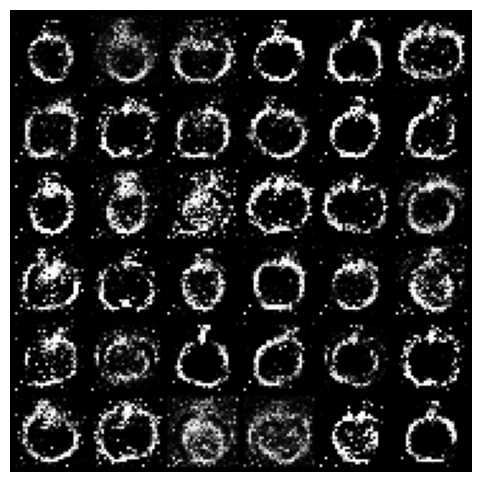

In [9]:
final_epoch, final_lossD, final_lossG, final_val_acc = history[-1]
print("FINAL_METRIC val_D_acc =", final_val_acc)

show_samples(G, n=36)

## 5) Save model weights

In [10]:
torch.save(G.state_dict(), "G_quickdraw_apple.pt")
torch.save(D.state_dict(), "D_quickdraw_apple.pt")
print("Saved weights: G_quickdraw_apple.pt, D_quickdraw_apple.pt")

Saved weights: G_quickdraw_apple.pt, D_quickdraw_apple.pt
